# Round 1 Strategy Exploration

This notebook turns the Round 1 EDA into a reusable signal -> strategy -> backtest workflow for:

- `ASH_COATED_OSMIUM`
- `INTARIAN_PEPPER_ROOT`

The focus is structural and interpretable:

- fixed fair vs dynamic fair
- imbalance and microprice validation
- explicit `take -> clear -> make` behavior
- side-by-side execution assumptions


In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import replace
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from imc_eda.round1 import load_prices, load_trades
from imc_eda.round1.strategy import (
    DynamicFairMeanReverter,
    FixedFairMarketMaker,
    ImbalanceMicropriceStrategy,
    align_trades_to_quotes,
    compute_features,
    estimate_fill_probabilities,
    estimate_quote_ev,
    evaluate_trade_impact,
    make_future_targets,
    prepare_execution_context,
    prepare_quotes,
    run_backtest,
    validate_mean_reversion,
    validate_signal_monotonicity,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.max_columns = 200
FIGURES_DIR = ROOT / "reports" / "figures" / "strategy-exploration"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
PRODUCTS = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]
FIXED_FAIRS = {"ASH_COATED_OSMIUM": 10000.0}
HORIZONS = (1, 5, 10, 20)
FILL_LOOKAHEAD = 5
EXECUTION_STYLES = ("aggressive", "passive", "improved")
HARD_POSITION_LIMITS = {product: 20 for product in PRODUCTS}
SOFT_POSITION_LIMITS = {product: 15 for product in PRODUCTS}

FIXED_GRID = list(product([1, 2, 3], [0, 1, 2], [2, 3, 4], [0.0, 0.25, 0.5], [1, 3, 5]))
DYNAMIC_GRID = list(product(["wall_mid", "book_mid_ema_50", "wall_mid_ema_50"], [1.0, 1.5, 2.0], [0.0, 0.25, 0.5], [1, 3, 5]))
IMBALANCE_GRID = list(product(["imbalance", "microprice_minus_mid"], [0.6, 0.7, 0.8], [1, 5, 10], [1, 3, 5]))

SHORTLIST_PER_FAMILY = 3
VALIDATION_FAIR_COLUMNS = [
    "wall_mid",
    "book_mid_rolling_mean_50",
    "book_mid_ema_50",
    "wall_mid_ema_50",
]
VALIDATION_SIGNAL_COLUMNS = ["imbalance", "microprice_minus_mid"]


## Setup

Load Round 1 quotes and trades, sort them, clean missing top-of-book values, and prepare reusable feature tables.


In [3]:
raw_prices = load_prices(file_format="csv")
raw_trades = load_trades(file_format="csv")

quotes = prepare_quotes(raw_prices)
features = make_future_targets(compute_features(quotes), horizons=HORIZONS)

for product, fair in FIXED_FAIRS.items():
    features[f"{product.lower()}_fixed_fair_edge"] = np.where(
        features["product"] == product,
        features["book_mid"] - fair,
        np.nan,
    )

aligned_trades = align_trades_to_quotes(features, raw_trades)

inventory = pd.DataFrame(
    {
        "frame": ["quotes", "features", "aligned_trades"],
        "rows": [len(quotes), len(features), len(aligned_trades)],
        "products": [
            sorted(quotes["product"].unique().tolist()),
            sorted(features["product"].unique().tolist()),
            sorted(aligned_trades["product"].unique().tolist()),
        ],
    }
)
display(inventory)

quote_health = (
    features.groupby("product")
    .agg(
        rows=("book_mid", "size"),
        mean_spread=("spread", "mean"),
        missing_microprice=("microprice", lambda s: float(s.isna().mean())),
        missing_wall_mid=("wall_mid", lambda s: float(s.isna().mean())),
        quote_timestamps=("timestamp", "nunique"),
    )
    .round(4)
)
display(quote_health)


,frame,rows,products
0,quotes,59997,"[ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT]"
1,features,59997,"[ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT]"
2,aligned_trades,2276,"[ASH_COATED_OSMIUM, INTARIAN_PEPPER_ROOT]"


,rows,mean_spread,missing_microprice,missing_wall_mid,quote_timestamps
product,,,,,
ASH_COATED_OSMIUM,29997,16.1730,0.0,0.0,9999
INTARIAN_PEPPER_ROOT,30000,13.0395,0.0,0.0,10000


## Feature Engineering

The feature set below is entirely built from reusable functions in `imc_eda.round1.strategy`.


In [4]:
feature_preview_columns = [
    "day",
    "timestamp",
    "product",
    "bid_price_1",
    "ask_price_1",
    "book_mid",
    "spread",
    "microprice",
    "imbalance",
    "wall_mid",
    "book_mid_rolling_mean_50",
    "book_mid_ema_50",
    "wall_mid_ema_50",
    "future_return_5",
]

display(features[feature_preview_columns].head())

feature_summary = (
    features.groupby("product")
    .agg(
        mean_mid=("book_mid", "mean"),
        mid_std=("book_mid", "std"),
        mean_microprice_minus_mid=("microprice_minus_mid", "mean"),
        mean_imbalance=("imbalance", "mean"),
        mean_wall_minus_mid=("wall_mid_minus_mid", "mean"),
    )
    .round(4)
)
display(feature_summary)


,day,timestamp,product,bid_price_1,ask_price_1,book_mid,spread,microprice,imbalance,wall_mid,book_mid_rolling_mean_50,book_mid_ema_50,wall_mid_ema_50,future_return_5
0,-2,100,ASH_COATED_OSMIUM,9992.0,10008.0,10000.0,16.0,10000.0,0.0,10001.5,NaN,NaN,NaN,-0.5
1,-2,200,ASH_COATED_OSMIUM,9992.0,10008.0,10000.0,16.0,10000.0,0.0,9999.5,NaN,NaN,NaN,0.5
2,-2,300,ASH_COATED_OSMIUM,9992.0,10008.0,10000.0,16.0,10000.0,0.0,9999.5,NaN,NaN,NaN,2.0
3,-2,400,ASH_COATED_OSMIUM,9992.0,10008.0,10000.0,16.0,10000.0,0.0,9999.5,NaN,NaN,NaN,-4.5
4,-2,500,ASH_COATED_OSMIUM,9992.0,10008.0,10000.0,16.0,10000.0,0.0,9999.5,NaN,NaN,NaN,-0.5


,mean_mid,mid_std,mean_microprice_minus_mid,mean_imbalance,mean_wall_minus_mid
product,,,,,
ASH_COATED_OSMIUM,10000.2026,4.8553,-0.0242,-0.0019,0.0267
INTARIAN_PEPPER_ROOT,11499.9229,866.0443,0.0042,0.0011,-3.0128


## Signal Validation

We validate fair-value edges, imbalance, and microprice before turning them into strategies.


In [5]:
mean_reversion_summary, mean_reversion_buckets = validate_mean_reversion(
    features,
    fair_columns=VALIDATION_FAIR_COLUMNS,
    horizons=HORIZONS,
)

signal_summary, signal_buckets = validate_signal_monotonicity(
    features,
    signal_columns=VALIDATION_SIGNAL_COLUMNS,
    horizons=HORIZONS,
)

future_mid_comparison_rows = []
for product_name in PRODUCTS:
    product_frame = features[features["product"] == product_name].copy()
    for horizon in HORIZONS:
        future_mid_column = f"future_mid_{horizon}"
        subset = product_frame[["book_mid", "microprice", future_mid_column]].dropna()
        if subset.empty:
            continue
        future_mid_comparison_rows.append(
            {
                "product": product_name,
                "horizon": horizon,
                "mid_to_future_mid_corr": subset["book_mid"].corr(subset[future_mid_column]),
                "microprice_to_future_mid_corr": subset["microprice"].corr(subset[future_mid_column]),
            }
        )

future_mid_comparison = pd.DataFrame(future_mid_comparison_rows)
trade_impact_summary = evaluate_trade_impact(aligned_trades, horizons=HORIZONS)

display(mean_reversion_summary.sort_values(["product", "horizon", "fair_column"]).round(4))
display(signal_summary.sort_values(["product", "horizon", "signal_column"]).round(4))
display(future_mid_comparison.round(4))
display(trade_impact_summary.round(4))

mean_reversion_scores = (
    mean_reversion_summary.assign(score=lambda df: -df["correlation"])
    .sort_values(["product", "score"], ascending=[True, False])
    .reset_index(drop=True)
)
signal_scores = (
    signal_summary.assign(score=lambda df: df["correlation"].abs())
    .sort_values(["product", "score"], ascending=[True, False])
    .reset_index(drop=True)
)
display(mean_reversion_scores.groupby("product").head(5).round(4))
display(signal_scores.groupby("product").head(5).round(4))


,product,correlation,observations,edge_std,future_return_std,fair_column,horizon
16,ASH_COATED_OSMIUM,-0.5285,29961,1.6717,1.8900,book_mid_ema_50,1
8,ASH_COATED_OSMIUM,-0.4980,29961,1.8114,1.8900,book_mid_rolling_mean_50,1
0,ASH_COATED_OSMIUM,-0.5544,29994,1.6581,1.8898,wall_mid,1
24,ASH_COATED_OSMIUM,-0.4715,29961,1.9545,1.8900,wall_mid_ema_50,1
18,ASH_COATED_OSMIUM,-0.5102,29949,1.6720,2.0071,book_mid_ema_50,5
10,ASH_COATED_OSMIUM,-0.4812,29949,1.8116,2.0071,book_mid_rolling_mean_50,5
2,ASH_COATED_OSMIUM,-0.5355,29982,1.6584,2.0069,wall_mid,5
26,ASH_COATED_OSMIUM,-0.4575,29949,1.9548,2.0071,wall_mid_ema_50,5
20,ASH_COATED_OSMIUM,-0.4888,29934,1.6722,2.1314,book_mid_ema_50,10
12,ASH_COATED_OSMIUM,-0.4617,29934,1.8119,2.1314,book_mid_rolling_mean_50,10


,product,correlation,observations,signal_std,future_return_std,signal_column,horizon
0,ASH_COATED_OSMIUM,0.5738,29994,0.2341,1.8898,imbalance,1
8,ASH_COATED_OSMIUM,0.4880,29994,1.7902,1.8898,microprice_minus_mid,1
2,ASH_COATED_OSMIUM,0.5517,29982,0.2341,2.0069,imbalance,5
10,ASH_COATED_OSMIUM,0.4705,29982,1.7901,2.0069,microprice_minus_mid,5
4,ASH_COATED_OSMIUM,0.5179,29967,0.2341,2.1309,imbalance,10
12,ASH_COATED_OSMIUM,0.4390,29967,1.7900,2.1309,microprice_minus_mid,10
6,ASH_COATED_OSMIUM,0.4753,29937,0.2341,2.3520,imbalance,20
14,ASH_COATED_OSMIUM,0.4064,29937,1.7902,2.3520,microprice_minus_mid,20
1,INTARIAN_PEPPER_ROOT,0.5510,29997,0.1936,1.7079,imbalance,1
9,INTARIAN_PEPPER_ROOT,0.4498,29997,1.3834,1.7079,microprice_minus_mid,1


,product,horizon,mid_to_future_mid_corr,microprice_to_future_mid_corr
0,ASH_COATED_OSMIUM,1,0.9242,0.9262
1,ASH_COATED_OSMIUM,5,0.9146,0.9182
2,ASH_COATED_OSMIUM,10,0.9037,0.9066
3,ASH_COATED_OSMIUM,20,0.8826,0.8871
4,INTARIAN_PEPPER_ROOT,1,1.0000,1.0000
5,INTARIAN_PEPPER_ROOT,5,1.0000,1.0000
6,INTARIAN_PEPPER_ROOT,10,1.0000,1.0000
7,INTARIAN_PEPPER_ROOT,20,1.0000,1.0000


,product,inferred_side,trades,mean_impact,median_impact,mean_quantity,horizon
0,ASH_COATED_OSMIUM,buy,647,0.1770,0.0,5.2102,1
1,ASH_COATED_OSMIUM,sell,618,-0.1133,0.0,5.2136,1
2,INTARIAN_PEPPER_ROOT,buy,493,1.7292,0.5,5.2008,1
3,INTARIAN_PEPPER_ROOT,sell,518,-1.0309,0.0,5.1467,1
4,ASH_COATED_OSMIUM,buy,647,0.0703,0.0,5.2102,5
5,ASH_COATED_OSMIUM,sell,618,-0.0097,0.0,5.2136,5
6,INTARIAN_PEPPER_ROOT,buy,493,2.2688,1.5,5.2008,5
7,INTARIAN_PEPPER_ROOT,sell,518,-0.7365,0.0,5.1467,5
8,ASH_COATED_OSMIUM,buy,647,0.1546,0.0,5.2102,10
9,ASH_COATED_OSMIUM,sell,618,-0.0663,0.0,5.2136,10


,product,correlation,observations,edge_std,future_return_std,fair_column,horizon,score
0,ASH_COATED_OSMIUM,-0.5544,29994,1.6581,1.8898,wall_mid,1,0.5544
1,ASH_COATED_OSMIUM,-0.5355,29982,1.6584,2.0069,wall_mid,5,0.5355
2,ASH_COATED_OSMIUM,-0.5285,29961,1.6717,1.8900,book_mid_ema_50,1,0.5285
3,ASH_COATED_OSMIUM,-0.5127,29967,1.6586,2.1309,wall_mid,10,0.5127
4,ASH_COATED_OSMIUM,-0.5102,29949,1.6720,2.0071,book_mid_ema_50,5,0.5102
16,INTARIAN_PEPPER_ROOT,-0.7038,29952,1.2033,1.7647,book_mid_ema_50,5,0.7038
17,INTARIAN_PEPPER_ROOT,-0.7029,29952,1.2297,1.7647,book_mid_rolling_mean_50,5,0.7029
18,INTARIAN_PEPPER_ROOT,-0.6947,29937,1.2035,1.7435,book_mid_ema_50,10,0.6947
19,INTARIAN_PEPPER_ROOT,-0.6938,29937,1.2298,1.7435,book_mid_rolling_mean_50,10,0.6938
20,INTARIAN_PEPPER_ROOT,-0.6933,29907,1.2037,1.7391,book_mid_ema_50,20,0.6933


,product,correlation,observations,signal_std,future_return_std,signal_column,horizon,score
0,ASH_COATED_OSMIUM,0.5738,29994,0.2341,1.8898,imbalance,1,0.5738
1,ASH_COATED_OSMIUM,0.5517,29982,0.2341,2.0069,imbalance,5,0.5517
2,ASH_COATED_OSMIUM,0.5179,29967,0.2341,2.1309,imbalance,10,0.5179
3,ASH_COATED_OSMIUM,0.4880,29994,1.7902,1.8898,microprice_minus_mid,1,0.4880
4,ASH_COATED_OSMIUM,0.4753,29937,0.2341,2.3520,imbalance,20,0.4753
8,INTARIAN_PEPPER_ROOT,0.5659,29970,0.1936,1.7430,imbalance,10,0.5659
9,INTARIAN_PEPPER_ROOT,0.5610,29940,0.1936,1.7390,imbalance,20,0.5610
10,INTARIAN_PEPPER_ROOT,0.5576,29985,0.1936,1.7644,imbalance,5,0.5576
11,INTARIAN_PEPPER_ROOT,0.5510,29997,0.1936,1.7079,imbalance,1,0.5510
12,INTARIAN_PEPPER_ROOT,0.4617,29970,1.3832,1.7430,microprice_minus_mid,10,0.4617


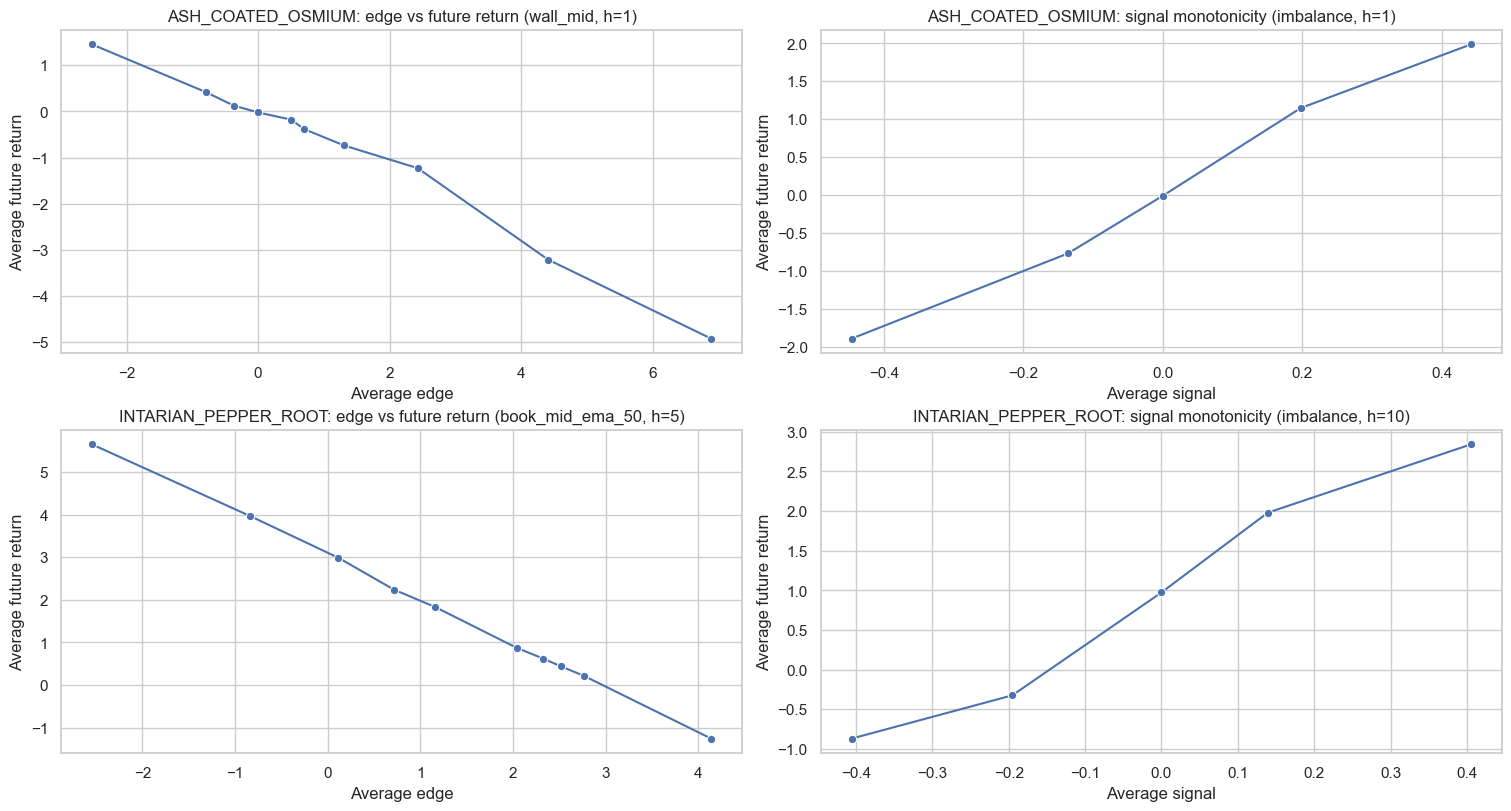

WindowsPath('F:/Projects/imc/imc-prosperity/reports/figures/strategy-exploration/signal-validation-overview.png')

In [6]:
selected_fairs = {
    product_name: mean_reversion_scores.loc[mean_reversion_scores["product"] == product_name, "fair_column"].head(2).tolist()
    for product_name in PRODUCTS
}
selected_signals = {
    product_name: signal_scores.loc[signal_scores["product"] == product_name, "signal_column"].head(2).tolist()
    for product_name in PRODUCTS
}

fig, axes = plt.subplots(len(PRODUCTS), 2, figsize=(15, 8), constrained_layout=True)
for row_index, product_name in enumerate(PRODUCTS):
    fair_name = selected_fairs[product_name][0]
    horizon = int(
        mean_reversion_scores.loc[
            (mean_reversion_scores["product"] == product_name) & (mean_reversion_scores["fair_column"] == fair_name),
            "horizon",
        ].iloc[0]
    )
    bucket_data = mean_reversion_buckets[
        (mean_reversion_buckets["product"] == product_name)
        & (mean_reversion_buckets["fair_column"] == fair_name)
        & (mean_reversion_buckets["horizon"] == horizon)
    ]
    sns.lineplot(data=bucket_data, x="avg_edge", y="avg_future_return", marker="o", ax=axes[row_index, 0])
    axes[row_index, 0].set_title(f"{product_name}: edge vs future return ({fair_name}, h={horizon})")
    axes[row_index, 0].set_xlabel("Average edge")
    axes[row_index, 0].set_ylabel("Average future return")

    signal_name = selected_signals[product_name][0]
    horizon_signal = int(
        signal_scores.loc[
            (signal_scores["product"] == product_name) & (signal_scores["signal_column"] == signal_name),
            "horizon",
        ].iloc[0]
    )
    bucket_signal = signal_buckets[
        (signal_buckets["product"] == product_name)
        & (signal_buckets["signal_column"] == signal_name)
        & (signal_buckets["horizon"] == horizon_signal)
    ]
    sns.lineplot(data=bucket_signal, x="avg_signal", y="avg_future_return", marker="o", ax=axes[row_index, 1])
    axes[row_index, 1].set_title(f"{product_name}: signal monotonicity ({signal_name}, h={horizon_signal})")
    axes[row_index, 1].set_xlabel("Average signal")
    axes[row_index, 1].set_ylabel("Average future return")

validation_plot_path = FIGURES_DIR / "signal-validation-overview.png"
fig.savefig(validation_plot_path, dpi=150, bbox_inches="tight")
plt.show()
validation_plot_path


## Execution Diagnostics

Estimate fill rates and quote EV under aggressive, passive, and improved quoting assumptions.


,product,execution_style,side,fill_probability,samples,mean_spread
0,ASH_COATED_OSMIUM,aggressive,buy,1.0000,29997,16.1730
1,ASH_COATED_OSMIUM,aggressive,sell,1.0000,29997,16.1730
2,ASH_COATED_OSMIUM,improved,buy,0.0861,29997,16.1730
3,ASH_COATED_OSMIUM,improved,sell,0.0890,29997,16.1730
4,ASH_COATED_OSMIUM,passive,buy,0.0726,29997,16.1730
5,ASH_COATED_OSMIUM,passive,sell,0.0755,29997,16.1730
6,INTARIAN_PEPPER_ROOT,aggressive,buy,1.0000,30000,13.0395
7,INTARIAN_PEPPER_ROOT,aggressive,sell,1.0000,30000,13.0395
8,INTARIAN_PEPPER_ROOT,improved,buy,0.0557,30000,13.0395
9,INTARIAN_PEPPER_ROOT,improved,sell,0.0508,30000,13.0395


,product,edge_bucket,mean_abs_edge,observations,execution_style,fill_probability,ev,edge_source
0,ASH_COATED_OSMIUM,0.0,0.8955,4683,aggressive,1.0000,0.8955,fixed_or_best_fair
1,ASH_COATED_OSMIUM,1.0,1.8764,4683,aggressive,1.0000,1.8764,fixed_or_best_fair
2,ASH_COATED_OSMIUM,2.0,2.8543,4683,aggressive,1.0000,2.8543,fixed_or_best_fair
3,ASH_COATED_OSMIUM,3.0,4.1220,4682,aggressive,1.0000,4.1220,fixed_or_best_fair
4,ASH_COATED_OSMIUM,4.0,5.8066,4683,aggressive,1.0000,5.8066,fixed_or_best_fair
5,ASH_COATED_OSMIUM,5.0,9.1501,4683,aggressive,1.0000,9.1501,fixed_or_best_fair
6,ASH_COATED_OSMIUM,0.0,0.8955,4683,improved,0.0876,0.0784,fixed_or_best_fair
7,ASH_COATED_OSMIUM,1.0,1.8764,4683,improved,0.0876,0.1644,fixed_or_best_fair
8,ASH_COATED_OSMIUM,2.0,2.8543,4683,improved,0.0876,0.2500,fixed_or_best_fair
9,ASH_COATED_OSMIUM,3.0,4.1220,4682,improved,0.0876,0.3611,fixed_or_best_fair


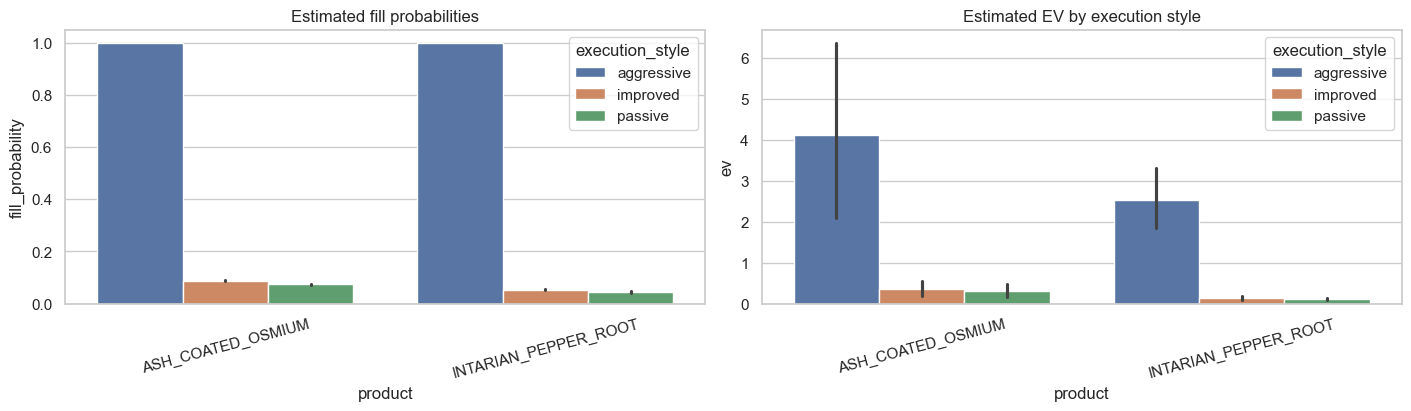

WindowsPath('F:/Projects/imc/imc-prosperity/reports/figures/strategy-exploration/execution-diagnostics.png')

In [7]:
fill_probabilities = estimate_fill_probabilities(features, aligned_trades, lookahead=FILL_LOOKAHEAD)

ev_frames = []
for product_name in PRODUCTS:
    product_frame = features[features["product"] == product_name].copy()
    if product_name in FIXED_FAIRS:
        product_frame["edge_for_ev"] = product_frame["book_mid"] - FIXED_FAIRS[product_name]
    else:
        fair_name = selected_fairs[product_name][0]
        product_frame["edge_for_ev"] = product_frame["book_mid"] - product_frame[fair_name]
    ev_frame = estimate_quote_ev(product_frame, fill_probabilities, edge_column="edge_for_ev")
    ev_frames.append(ev_frame.assign(edge_source="fixed_or_best_fair"))

execution_ev = pd.concat(ev_frames, ignore_index=True)
display(fill_probabilities.round(4))
display(execution_ev.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.barplot(data=fill_probabilities, x="product", y="fill_probability", hue="execution_style", ax=axes[0])
axes[0].set_title("Estimated fill probabilities")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=execution_ev, x="product", y="ev", hue="execution_style", ax=axes[1])
axes[1].set_title("Estimated EV by execution style")
axes[1].tick_params(axis="x", rotation=15)

execution_plot_path = FIGURES_DIR / "execution-diagnostics.png"
fig.savefig(execution_plot_path, dpi=150, bbox_inches="tight")
plt.show()
execution_plot_path


## Strategy Definitions

Use explicit parameter grids, then shortlist the most plausible configs per family before full backtests so the notebook stays interactive.


In [8]:
def build_fixed_candidates(product_name: str) -> list[BaseException]:
    fair_value = FIXED_FAIRS.get(product_name, float(features.loc[features["product"] == product_name, "book_mid"].mean()))
    grid = pd.DataFrame(
        FIXED_GRID,
        columns=["take_width", "clear_width", "make_width", "inventory_skew", "order_size"],
    )
    grid["heuristic"] = (
        -abs(grid["take_width"] - 2)
        -abs(grid["clear_width"] - 1)
        -abs(grid["make_width"] - 3)
        -abs(grid["order_size"] - 3) / 2
        -abs(grid["inventory_skew"] - 0.25)
    )
    candidates = []
    for row in grid.sort_values("heuristic", ascending=False).head(SHORTLIST_PER_FAMILY).itertuples(index=False):
        config = {
            "fair_value": fair_value,
            "take_width": int(row.take_width),
            "clear_width": int(row.clear_width),
            "make_width": int(row.make_width),
            "soft_position_limit": SOFT_POSITION_LIMITS[product_name],
            "hard_position_limit": HARD_POSITION_LIMITS[product_name],
            "inventory_skew": float(row.inventory_skew),
            "order_size": int(row.order_size),
        }
        candidates.append(
            FixedFairMarketMaker(
                name=f"{product_name.lower()}_fixed_tw{row.take_width}_cw{row.clear_width}_mw{row.make_width}_s{row.order_size}",
                config=config,
            )
        )
    return candidates


def build_dynamic_candidates(product_name: str) -> list[BaseException]:
    product_scores = mean_reversion_scores[mean_reversion_scores["product"] == product_name].copy()
    fair_priority = product_scores.groupby("fair_column")["score"].mean().to_dict()
    grid = pd.DataFrame(
        DYNAMIC_GRID,
        columns=["fair_source", "entry_threshold", "inventory_skew", "order_size"],
    )
    grid["fair_score"] = grid["fair_source"].map(fair_priority).fillna(0.0)
    grid["heuristic"] = grid["fair_score"] - abs(grid["entry_threshold"] - 1.5) - abs(grid["order_size"] - 3) / 2 - abs(grid["inventory_skew"] - 0.25)
    candidates = []
    for row in grid.sort_values("heuristic", ascending=False).head(SHORTLIST_PER_FAMILY).itertuples(index=False):
        config = {
            "fair_source": row.fair_source,
            "entry_threshold": float(row.entry_threshold),
            "exit_threshold": float(row.entry_threshold) * 0.5,
            "soft_position_limit": SOFT_POSITION_LIMITS[product_name],
            "hard_position_limit": HARD_POSITION_LIMITS[product_name],
            "inventory_skew": float(row.inventory_skew),
            "order_size": int(row.order_size),
            "make_width": 1.0,
        }
        candidates.append(
            DynamicFairMeanReverter(
                name=f"{product_name.lower()}_dynamic_{row.fair_source}_et{row.entry_threshold}_s{row.order_size}",
                config=config,
            )
        )
    return candidates


def build_imbalance_candidates(product_name: str, reference_frame: pd.DataFrame) -> list[BaseException]:
    product_scores = signal_scores[signal_scores["product"] == product_name].copy()
    signal_priority = product_scores.groupby("signal_column")["score"].mean().to_dict()
    best_horizon_by_signal = (
        product_scores.sort_values("score", ascending=False)
        .drop_duplicates("signal_column")
        .set_index("signal_column")["horizon"]
        .to_dict()
    )
    grid = pd.DataFrame(
        IMBALANCE_GRID,
        columns=["signal_source", "quantile", "holding_horizon", "order_size"],
    )
    grid["signal_score"] = grid["signal_source"].map(signal_priority).fillna(0.0)
    grid["preferred_horizon"] = grid["signal_source"].map(best_horizon_by_signal).fillna(grid["holding_horizon"])
    grid["heuristic"] = grid["signal_score"] - abs(grid["holding_horizon"] - grid["preferred_horizon"]) / 10 - abs(grid["quantile"] - 0.7) - abs(grid["order_size"] - 3) / 2
    candidates = []
    for row in grid.sort_values("heuristic", ascending=False).head(SHORTLIST_PER_FAMILY).itertuples(index=False):
        product_frame = reference_frame[reference_frame["product"] == product_name]
        threshold = float(product_frame[row.signal_source].abs().quantile(float(row.quantile)))
        config = {
            "signal_source": row.signal_source,
            "signal_threshold": threshold,
            "holding_horizon": int(row.holding_horizon),
            "soft_position_limit": SOFT_POSITION_LIMITS[product_name],
            "hard_position_limit": HARD_POSITION_LIMITS[product_name],
            "order_size": int(row.order_size),
        }
        candidates.append(
            ImbalanceMicropriceStrategy(
                name=f"{product_name.lower()}_signal_{row.signal_source}_q{row.quantile}_h{row.holding_horizon}_s{row.order_size}",
                config=config,
            )
        )
    return candidates


def build_candidates(product_name: str, reference_frame: pd.DataFrame) -> list:
    return (
        build_fixed_candidates(product_name)
        + build_dynamic_candidates(product_name)
        + build_imbalance_candidates(product_name, reference_frame)
    )


## Backtests

Tune on days `-2` and `-1`, evaluate winners on day `0`, and also compare aggregate all-day performance.


In [9]:
def choose_best(summary_frame: pd.DataFrame) -> pd.Series:
    ranked = summary_frame.sort_values(
        ["total_pnl", "simple_sharpe", "max_drawdown", "trade_count"],
        ascending=[False, False, True, False],
    )
    return ranked.iloc[0]


def evaluate_candidates(product_name: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    product_features = features[features["product"] == product_name].copy()
    product_trades = aligned_trades[aligned_trades["product"] == product_name].copy()

    train_features = product_features[product_features["day"].isin([-2, -1])].copy()
    holdout_features = product_features[product_features["day"] == 0].copy()

    train_context = prepare_execution_context(train_features, product_trades[product_trades["day"].isin([-2, -1])], lookahead=FILL_LOOKAHEAD)
    holdout_context = prepare_execution_context(holdout_features, product_trades[product_trades["day"] == 0], lookahead=FILL_LOOKAHEAD)
    aggregate_context = prepare_execution_context(product_features, product_trades, lookahead=FILL_LOOKAHEAD)

    candidates = build_candidates(product_name, train_features)
    candidate_lookup = {candidate.name: candidate for candidate in candidates}

    tuning_rows = []
    aggregate_rows = []
    diagnostics = {}

    for candidate in candidates:
        for execution_style in EXECUTION_STYLES:
            train_result = run_backtest(train_context, product_trades, candidate, execution_style, hard_position_limit=HARD_POSITION_LIMITS[product_name], fill_horizon=FILL_LOOKAHEAD)
            train_summary = train_result["summary"] | {
                "product": product_name,
                "candidate_name": candidate.name,
                "family": candidate.__class__.__name__,
                "params": json.dumps(candidate.config, sort_keys=True),
                "evaluation_mode": "train",
            }
            tuning_rows.append(train_summary)

            aggregate_result = run_backtest(aggregate_context, product_trades, candidate, execution_style, hard_position_limit=HARD_POSITION_LIMITS[product_name], fill_horizon=FILL_LOOKAHEAD)
            aggregate_summary = aggregate_result["summary"] | {
                "product": product_name,
                "candidate_name": candidate.name,
                "family": candidate.__class__.__name__,
                "params": json.dumps(candidate.config, sort_keys=True),
                "evaluation_mode": "aggregate",
            }
            aggregate_rows.append(aggregate_summary)
            diagnostics[(product_name, candidate.name, execution_style, "aggregate")] = aggregate_result

    tuning_frame = pd.DataFrame(tuning_rows)
    aggregate_frame = pd.DataFrame(aggregate_rows)

    best_train = choose_best(tuning_frame)
    best_candidate = candidate_lookup[best_train["candidate_name"]]
    holdout_result = run_backtest(holdout_context, product_trades[product_trades["day"] == 0], best_candidate, best_train["execution_style"], hard_position_limit=HARD_POSITION_LIMITS[product_name], fill_horizon=FILL_LOOKAHEAD)
    holdout_summary = pd.DataFrame(
        [
            holdout_result["summary"]
            | {
                "product": product_name,
                "candidate_name": best_candidate.name,
                "family": best_candidate.__class__.__name__,
                "params": json.dumps(best_candidate.config, sort_keys=True),
                "evaluation_mode": "holdout",
            }
        ]
    )
    diagnostics[(product_name, best_candidate.name, best_train["execution_style"], "holdout")] = holdout_result

    best_aggregate = pd.DataFrame([choose_best(aggregate_frame)])
    return holdout_summary, best_aggregate, diagnostics


holdout_winners = []
aggregate_winners = []
diagnostic_runs = {}
for product_name in PRODUCTS:
    holdout_summary, aggregate_summary, diagnostics = evaluate_candidates(product_name)
    holdout_winners.append(holdout_summary)
    aggregate_winners.append(aggregate_summary)
    diagnostic_runs.update(diagnostics)

holdout_winners = pd.concat(holdout_winners, ignore_index=True)
aggregate_winners = pd.concat(aggregate_winners, ignore_index=True)

display(holdout_winners.round(4))
display(aggregate_winners.round(4))


,strategy,execution_style,total_pnl,simple_sharpe,max_drawdown,trade_count,avg_inventory_usage,max_inventory_usage,fraction_near_limit,product,candidate_name,family,params,evaluation_mode
0,ash_coated_osmium_dynamic_wall_mid_et1.5_s3,improved,33885.0,0.1172,300.0,1859,0.6289,1.0,0.3873,ASH_COATED_OSMIUM,ash_coated_osmium_dynamic_wall_mid_et1.5_s3,DynamicFairMeanReverter,"{""entry_threshold"": 1.5, ""exit_threshold"": 0.7...",holdout
1,intarian_pepper_root_signal_imbalance_q0.6_h10_s3,improved,20461.0,0.0626,260.0,178,0.8686,1.0,0.7629,INTARIAN_PEPPER_ROOT,intarian_pepper_root_signal_imbalance_q0.6_h10_s3,ImbalanceMicropriceStrategy,"{""hard_position_limit"": 20, ""holding_horizon"":...",holdout


,strategy,execution_style,total_pnl,simple_sharpe,max_drawdown,trade_count,avg_inventory_usage,max_inventory_usage,fraction_near_limit,product,candidate_name,family,params,evaluation_mode
0,ash_coated_osmium_dynamic_wall_mid_ema_50_et1....,improved,105420.0,0.1233,300.0,5732,0.6325,1.0,0.3957,ASH_COATED_OSMIUM,ash_coated_osmium_dynamic_wall_mid_ema_50_et1....,DynamicFairMeanReverter,"{""entry_threshold"": 1.5, ""exit_threshold"": 0.7...",aggregate
1,intarian_pepper_root_signal_imbalance_q0.6_h10_s3,passive,62136.0,0.0677,260.0,514,0.8767,1.0,0.8060,INTARIAN_PEPPER_ROOT,intarian_pepper_root_signal_imbalance_q0.6_h10_s3,ImbalanceMicropriceStrategy,"{""hard_position_limit"": 20, ""holding_horizon"":...",aggregate


## Diagnostics

Inspect PnL, position, and entry/exit behavior for the winning strategies.


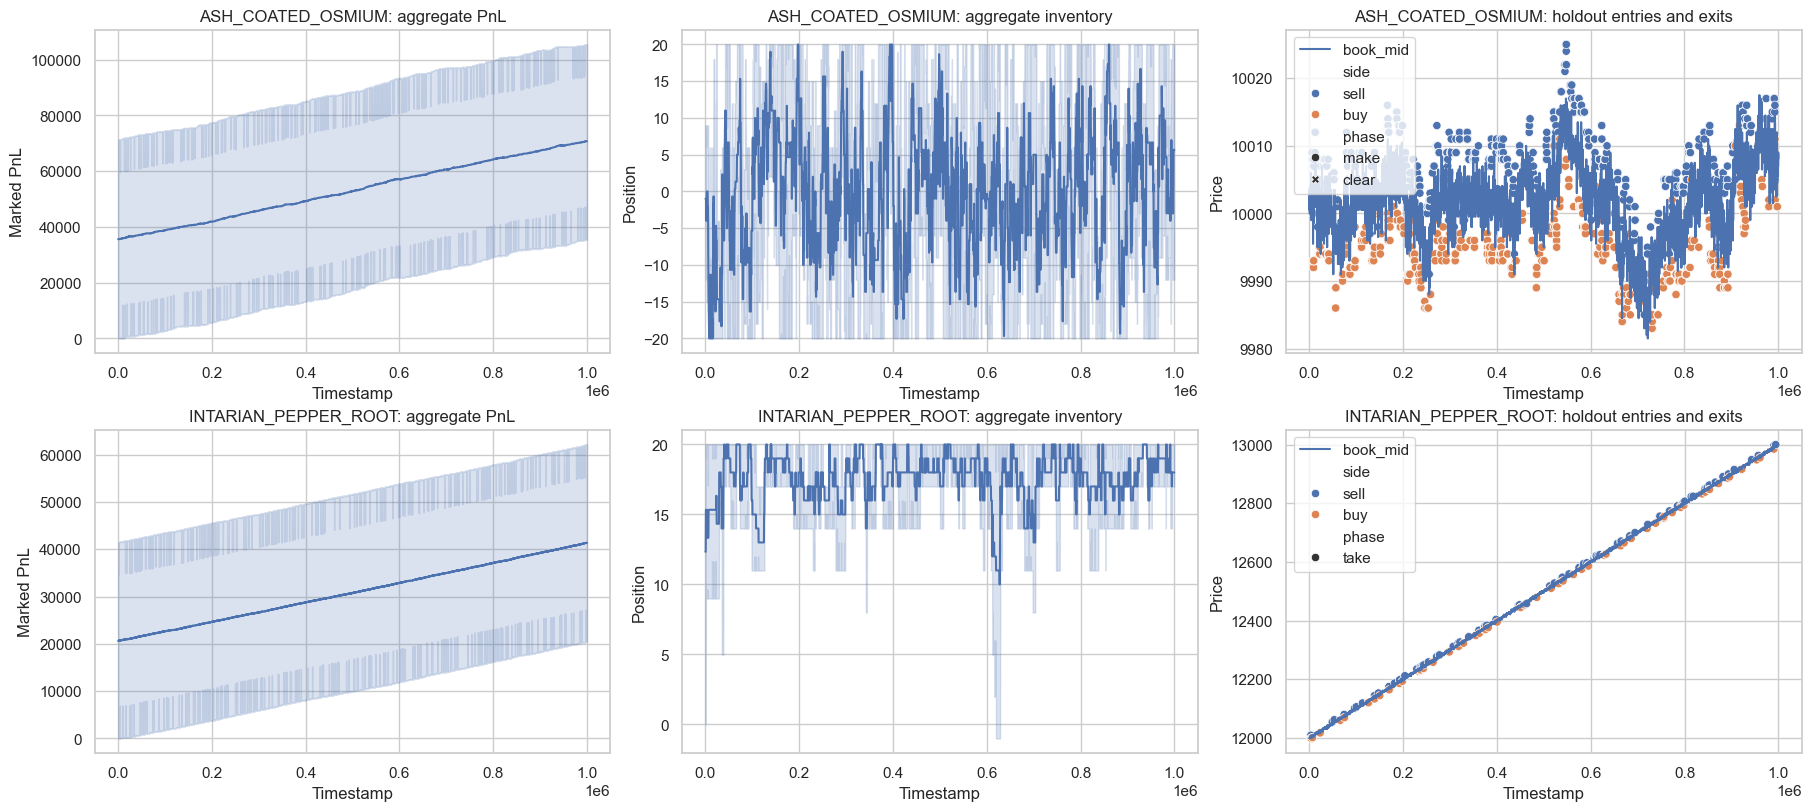

WindowsPath('F:/Projects/imc/imc-prosperity/reports/figures/strategy-exploration/best-strategy-diagnostics.png')

In [10]:
fig, axes = plt.subplots(len(PRODUCTS), 3, figsize=(18, 8), constrained_layout=True)
for row_index, product_name in enumerate(PRODUCTS):
    holdout_row = holdout_winners.loc[holdout_winners["product"] == product_name].iloc[0]
    aggregate_row = aggregate_winners.loc[aggregate_winners["product"] == product_name].iloc[0]

    holdout_run = diagnostic_runs[(product_name, holdout_row["candidate_name"], holdout_row["execution_style"], "holdout")]
    aggregate_run = diagnostic_runs[(product_name, aggregate_row["candidate_name"], aggregate_row["execution_style"], "aggregate")]

    holdout_curve = holdout_run["equity_curve"]
    aggregate_curve = aggregate_run["equity_curve"]
    aggregate_trades = aggregate_run["trades"]

    sns.lineplot(data=aggregate_curve, x="timestamp", y="marked_pnl", ax=axes[row_index, 0])
    axes[row_index, 0].set_title(f"{product_name}: aggregate PnL")
    axes[row_index, 0].set_xlabel("Timestamp")
    axes[row_index, 0].set_ylabel("Marked PnL")

    sns.lineplot(data=aggregate_curve, x="timestamp", y="position", ax=axes[row_index, 1])
    axes[row_index, 1].set_title(f"{product_name}: aggregate inventory")
    axes[row_index, 1].set_xlabel("Timestamp")
    axes[row_index, 1].set_ylabel("Position")

    price_frame = features[(features["product"] == product_name) & (features["day"] == 0)].copy()
    sns.lineplot(data=price_frame, x="timestamp", y="book_mid", ax=axes[row_index, 2], label="book_mid")
    if not holdout_run["trades"].empty:
        sns.scatterplot(
            data=holdout_run["trades"],
            x="timestamp",
            y="fill_price",
            hue="side",
            style="phase",
            ax=axes[row_index, 2],
        )
    axes[row_index, 2].set_title(f"{product_name}: holdout entries and exits")
    axes[row_index, 2].set_xlabel("Timestamp")
    axes[row_index, 2].set_ylabel("Price")

diagnostic_plot_path = FIGURES_DIR / "best-strategy-diagnostics.png"
fig.savefig(diagnostic_plot_path, dpi=150, bbox_inches="tight")
plt.show()
diagnostic_plot_path


## Output

Summarize the best holdout and aggregate strategies per product with their signals, execution choices, and tuned parameters.


In [11]:
final_summary = pd.concat([holdout_winners, aggregate_winners], ignore_index=True)
final_summary = final_summary[
    [
        "evaluation_mode",
        "product",
        "family",
        "candidate_name",
        "execution_style",
        "total_pnl",
        "simple_sharpe",
        "max_drawdown",
        "trade_count",
        "avg_inventory_usage",
        "fraction_near_limit",
        "params",
    ]
].sort_values(["product", "evaluation_mode"]).reset_index(drop=True)

display(final_summary.round(4))

for product_name in PRODUCTS:
    product_summary = final_summary[final_summary["product"] == product_name]
    print(f"\n{product_name}")
    for _, row in product_summary.iterrows():
        pnl_message = "profitable" if row["total_pnl"] > 0 else "not profitable under these assumptions"
        print(
            f"  {row['evaluation_mode']}: {row['family']} | execution={row['execution_style']} | pnl={row['total_pnl']:.2f} | sharpe={row['simple_sharpe']:.4f} | drawdown={row['max_drawdown']:.2f} | trades={int(row['trade_count'])} | {pnl_message}"
        )
        print(f"    params={row['params']}")


,evaluation_mode,product,family,candidate_name,execution_style,total_pnl,simple_sharpe,max_drawdown,trade_count,avg_inventory_usage,fraction_near_limit,params
0,aggregate,ASH_COATED_OSMIUM,DynamicFairMeanReverter,ash_coated_osmium_dynamic_wall_mid_ema_50_et1....,improved,105420.0,0.1233,300.0,5732,0.6325,0.3957,"{""entry_threshold"": 1.5, ""exit_threshold"": 0.7..."
1,holdout,ASH_COATED_OSMIUM,DynamicFairMeanReverter,ash_coated_osmium_dynamic_wall_mid_et1.5_s3,improved,33885.0,0.1172,300.0,1859,0.6289,0.3873,"{""entry_threshold"": 1.5, ""exit_threshold"": 0.7..."
2,aggregate,INTARIAN_PEPPER_ROOT,ImbalanceMicropriceStrategy,intarian_pepper_root_signal_imbalance_q0.6_h10_s3,passive,62136.0,0.0677,260.0,514,0.8767,0.8060,"{""hard_position_limit"": 20, ""holding_horizon"":..."
3,holdout,INTARIAN_PEPPER_ROOT,ImbalanceMicropriceStrategy,intarian_pepper_root_signal_imbalance_q0.6_h10_s3,improved,20461.0,0.0626,260.0,178,0.8686,0.7629,"{""hard_position_limit"": 20, ""holding_horizon"":..."



ASH_COATED_OSMIUM
  aggregate: DynamicFairMeanReverter | execution=improved | pnl=105420.00 | sharpe=0.1233 | drawdown=300.00 | trades=5732 | profitable
    params={"entry_threshold": 1.5, "exit_threshold": 0.75, "fair_source": "wall_mid_ema_50", "hard_position_limit": 20, "inventory_skew": 0.25, "make_width": 1.0, "order_size": 3, "soft_position_limit": 15}
  holdout: DynamicFairMeanReverter | execution=improved | pnl=33885.00 | sharpe=0.1172 | drawdown=300.00 | trades=1859 | profitable
    params={"entry_threshold": 1.5, "exit_threshold": 0.75, "fair_source": "wall_mid", "hard_position_limit": 20, "inventory_skew": 0.25, "make_width": 1.0, "order_size": 3, "soft_position_limit": 15}

INTARIAN_PEPPER_ROOT
  aggregate: ImbalanceMicropriceStrategy | execution=passive | pnl=62136.00 | sharpe=0.0677 | drawdown=260.00 | trades=514 | profitable
    params={"hard_position_limit": 20, "holding_horizon": 10, "order_size": 3, "signal_source": "imbalance", "signal_threshold": 0.0, "soft_positio